In [1]:
# plot mock-up

# first, we load the actual chidl data from 
f = '/Users/yumyum/Desktop/Projects/Box_task/child_data/trials.csv'

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(f)

# print table head
print(df.head())

# there are columns: ID,  Order,   Box, Key,  Worked, Error
# ID - child id
# Order - is attempt number
# box - string id of box
# key - string id of key
# Worked - 1 if the key worked, 0 if not

# get all boxes and keys
boxes = df['Box'].unique()
keys = df['Key'].unique()

# identify all children who opened all boxes
children = df['ID'].unique()
successful_children = []
for child in children:
    child_data = df[df['ID'] == child]
    opened_boxes = child_data[child_data['Worked'] == 1]['Box'].unique()
    if set(opened_boxes) == set(boxes):
        successful_children.append(child)

# numner of successful children
print("Number of successful children:", len(successful_children))


     ID  Order  StartTime    Time  Time_relStart    Box      Key  Worked  \
0  D001      1     244770  256537          11767    red      red       0   
1  D001      2     244770  261785          17015    red      red       1   
2  D001      3     244770  274659          29889   pink     pink       0   
3  D001      4     244770  285483          40713   pink    grey2       1   
4  D001      5     244770  300038          55268  white  orange4       1   

   Error  ColorMatch  NumMatch  ShapeMatch  
0      1           1         1           0  
1      0           1         1           0  
2      0           1         0           0  
3      0           0         1           0  
4      0           0         1           0  
Number of successful children: 66


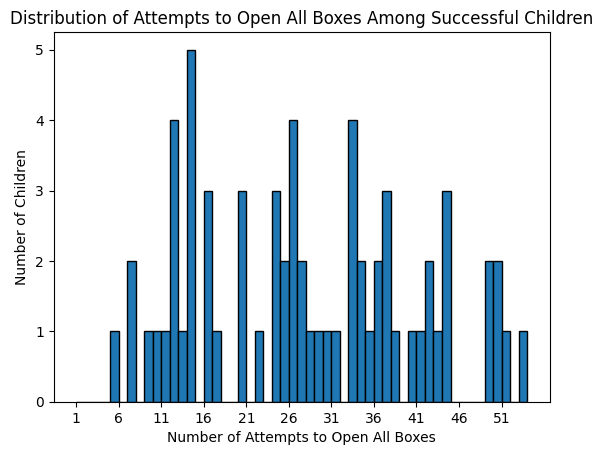

Mean number of attempts to open all boxes: 27.636363636363637
Standard deviation of attempts to open all boxes: 12.868373685991328


In [6]:
# now compute the number of attempts it took for each successful child to open all boxes
attempts_to_success = []
for child in successful_children:
    child_data = df[df['ID'] == child]
    attempts = 0
    opened_boxes = set()
    for index, row in child_data.iterrows():
        attempts += 1
        if row['Worked'] == 1:
            opened_boxes.add(row['Box'])
        if opened_boxes == set(boxes):
            break
    attempts_to_success.append(attempts)

# plot histogram of attempts to success
# ticks every 5 trials

plt.hist(attempts_to_success, bins=range(1, max(attempts_to_success)+1), edgecolor='black')
plt.xlabel('Number of Attempts to Open All Boxes')
plt.ylabel('Number of Children')
plt.title('Distribution of Attempts to Open All Boxes Among Successful Children')
plt.xticks(range(1, max(attempts_to_success)+1, 5))
plt.show()

# the count of attempst is in the variable attempts_to_success

# mean
mean_attempts = sum(attempts_to_success) / len(attempts_to_success)
print("Mean number of attempts to open all boxes:", mean_attempts)
sd = (sum((x - mean_attempts) ** 2 for x in attempts_to_success) / len(attempts_to_success)) ** 0.5
print("Standard deviation of attempts to open all boxes:", sd)

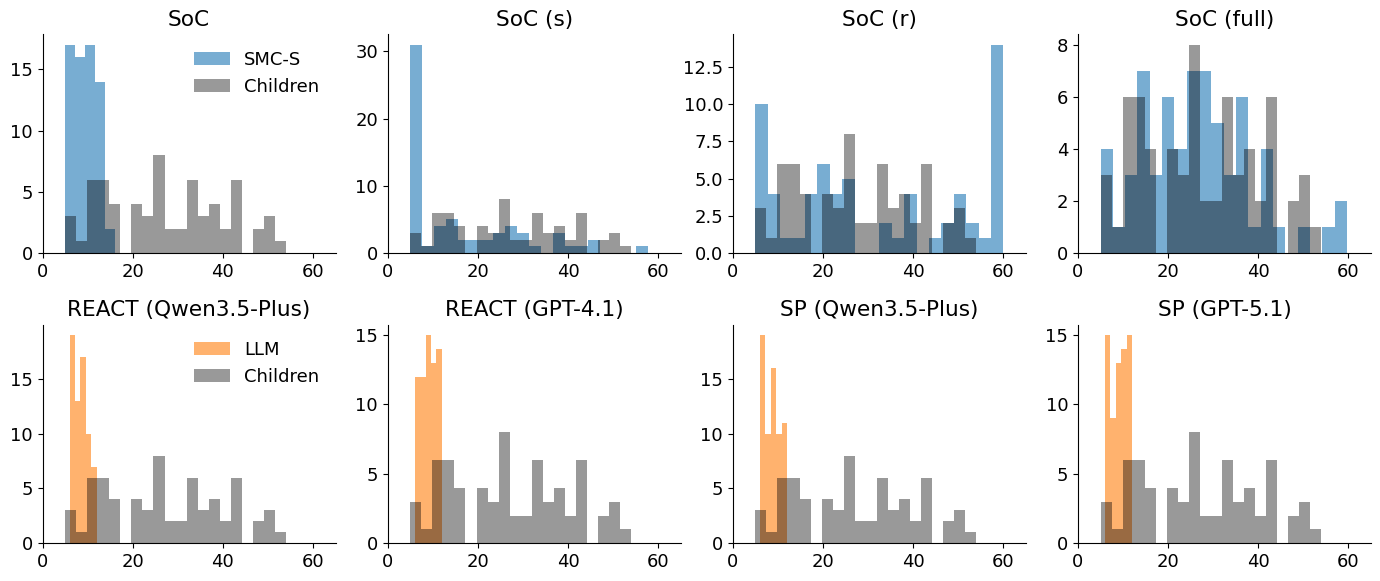

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume this exists
# attempts_to_success = np.array([...])

# --- helper to generate mock data ---
def generate_llm_data(n=66):
    # concentrated between 6–12, median ~7
    data = np.random.normal(loc=9, scale=2.2, size=n)
    return np.clip(data, 6, 12)

def generate_soc_data_full(n=66):
    # mean 27, sd 12.8, range ~5–60
    data = np.random.normal(loc=27, scale=12.8, size=n)
    return np.clip(data, 5, 60)

def generate_soc_data(n=66):
    # mean 9, sd 2.8, range ~5–60
    data = np.random.normal(loc=9, scale=2.8, size=n)
    return np.clip(data, 5, 60)

def generate_soc_data_r(n=66):
    # mean 30, sd 28, range ~5–60
    data = np.random.normal(loc=30, scale=28, size=n)
    return np.clip(data, 5, 60)

def generate_soc_data_s(n=66):
    # mean 30, sd 20, range ~5–60
    data = np.random.normal(loc=10, scale=20, size=n)
    return np.clip(data, 5, 60)

# --- labels ---
soc_labels = ["SoC", "SoC (s)", "SoC (r)", "SoC (full)"]
llm_labels = ["REACT (Qwen3.5-Plus)", "REACT (GPT-4.1)",
              "SP (Qwen3.5-Plus)", "SP (GPT-5.1)"]

soc_funcs = [generate_soc_data, generate_soc_data_s, generate_soc_data_r, generate_soc_data_full]

# --- plotting ---
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=False, sharey=False)

# Colors
soc_color = "tab:blue"
llm_color = "tab:orange"
child_color = "black"

# big font labels
plt.rcParams.update({'font.size': 13})

# --- Top row: SMC-S (SoC) ---
for i, label in enumerate(soc_labels):
    ax = axes[0, i]
    
    soc_data = soc_funcs[i]()
    
    if (i == 0): bins = 5
    else: bins = 20

    ax.hist(soc_data, bins=bins, alpha=0.6, label="SMC-S", color=soc_color)
    ax.hist(attempts_to_success, bins=20, alpha=0.4, label="Children", color=child_color)
    
    ax.set_title(label)
    ax.set_xlim(0, 65)

# --- Bottom row: LLM ---
for i, label in enumerate(llm_labels):
    ax = axes[1, i]
    
    llm_data = generate_llm_data()
    
    # make sure the bars are the same width for both histograms
    ax.hist(llm_data, bins=5, alpha=0.6, label="LLM", color=llm_color)

    ax.hist(attempts_to_success, bins=20, alpha=0.4, label="Children", color=child_color)

    
    ax.set_title(label)
    ax.set_xlim(0, 65)

# --- formatting ---
for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)

# each row has its own legend
axes[0, 0].legend(frameon=False)
axes[1, 0].legend(frameon=False)

#fig.suptitle("Model Simulations vs. Child Performance", fontsize=14)
fig.tight_layout()

plt.show()

In [ ]:
import json
import os
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
KID_DATA_PATH = r"C:\Users\MSN\Documents\Python\smc-s\data\Dolly_KeyEviModel_7.3.24.json"


# -----------------------------
# 4-panel inputs
# -----------------------------
MODEL_JSON_PATHS = [
    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\28thMar\theta_19_1__gen_0p01__priororder_0p05__runs_1000__trials_70__20260328_092116\theta_19_1__gen_0p01__priororder_0p05__runs_1000__trials_70__20260328_092116.json",
    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\28thMar\theta_2_2__gen_0p01__priororder_0p05__runs_1000__trials_70__20260328_203833\theta_2_2__gen_0p01__priororder_0p05__runs_1000__trials_70__20260328_203833.json",
    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\28thMar\theta_19_1__gen_0p6__priororder_0p05__runs_1000__trials_70__20260328_123515\theta_19_1__gen_0p6__priororder_0p05__runs_1000__trials_70__20260328_123515.json",
    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\trueprior0p02-0p04\theta_2_2__gen_0p6__priororder_0p023__runs_1000__trials_70__20260401_000422\theta_2_2__gen_0p6__priororder_0p023__runs_1000__trials_70__20260401_000422.json",
]


PANEL_TITLES = [
    "Lesioned Randomness and Skill",
    "Lesioned Skill",
    "Lesioned Randomness",
    "Full Model", #Normal Skill and Randomness
]

# -----------------------------
# 10-run overlay inputs
# -----------------------------
OVERLAY_10_JSON_PATHS = [
    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p04__runs_1000__trials_70__20260331_203343\theta_2_2__gen_0p6__priororder_0p04__runs_1000__trials_70__20260331_203343.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p042__runs_1000__trials_70__20260331_203404\theta_2_2__gen_0p6__priororder_0p042__runs_1000__trials_70__20260331_203404.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p044__runs_1000__trials_70__20260331_203426\theta_2_2__gen_0p6__priororder_0p044__runs_1000__trials_70__20260331_203426.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p046__runs_1000__trials_70__20260331_203447\theta_2_2__gen_0p6__priororder_0p046__runs_1000__trials_70__20260331_203447.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p048__runs_1000__trials_70__20260331_203507\theta_2_2__gen_0p6__priororder_0p048__runs_1000__trials_70__20260331_203507.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p05__runs_1000__trials_70__20260331_203527\theta_2_2__gen_0p6__priororder_0p05__runs_1000__trials_70__20260331_203527.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p052__runs_1000__trials_70__20260331_203546\theta_2_2__gen_0p6__priororder_0p052__runs_1000__trials_70__20260331_203546.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p054__runs_1000__trials_70__20260331_203606\theta_2_2__gen_0p6__priororder_0p054__runs_1000__trials_70__20260331_203606.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p056__runs_1000__trials_70__20260331_203623\theta_2_2__gen_0p6__priororder_0p056__runs_1000__trials_70__20260331_203623.json",

    r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\31stMar\theta_2_2__gen_0p6__priororder_0p058__runs_1000__trials_70__20260331_203641\theta_2_2__gen_0p6__priororder_0p058__runs_1000__trials_70__20260331_203641.json",
]

OUTPUT_4PANEL_PATH = r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\smc_s_first_row_4paneIGfit.png"
OUTPUT_10_OVERLAY_PATH = r"C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\smc_s_first_row_10pane3.png"

X_MAX_DISPLAY = 70
MODEL_SCALE = 0.1   # normalize 1000 model runs to ~100-child scale


# -----------------------------
# Child data loader
# -----------------------------
def load_kid_trials_needed(json_path: str):
    with open(json_path, "r", encoding="utf-8") as f:
        kid_data = json.load(f)

    trials_needed_list = []
    total_kids = len(kid_data)
    success_kids = 0

    for kid_id, trials in kid_data.items():
        opened_boxes = set()
        trial_count_to_5 = None

        for i, trial in enumerate(trials, start=1):
            box_id = trial[1]
            outcome = int(trial[2])

            if outcome == 1:
                opened_boxes.add(box_id)

            if len(opened_boxes) == 5:
                trial_count_to_5 = i
                break

        if trial_count_to_5 is not None:
            success_kids += 1
            trials_needed_list.append(trial_count_to_5)

    return trials_needed_list, success_kids, total_kids


# -----------------------------
# SMC-S model data loader
# -----------------------------
def load_model_trials_needed(json_path: str):
    with open(json_path, "r", encoding="utf-8") as f:
        model_data = json.load(f)

    if "attempt_counts" not in model_data:
        raise ValueError(f"Expected 'attempt_counts' in model JSON: {json_path}")

    attempt_counts = [int(x) for x in model_data["attempt_counts"]]
    num_runs = int(model_data.get("num_runs", len(attempt_counts)))

    return attempt_counts, num_runs, model_data


# -----------------------------
# 4-panel overlay plot
# -----------------------------
def plot_four_panels(
    kid_trials_needed,
    success_kids,
    total_kids,
    model_json_paths,
    panel_titles,
    save_path
):
    kid_plot_data = [x for x in kid_trials_needed if x <= X_MAX_DISPLAY]
    if len(kid_plot_data) == 0:
        raise ValueError("No child data left after clipping.")

    fig, axes = plt.subplots(1, 4, figsize=(12.4, 2.9), sharey=True)

    bins = range(0, X_MAX_DISPLAY + 2)

    # Marta top-row colors
    soc_color = "tab:blue"
    child_color = "black"

    for ax, model_json_path, title in zip(axes, model_json_paths, panel_titles):
        model_attempt_counts, num_runs, model_data = load_model_trials_needed(model_json_path)
        model_plot_data = [x for x in model_attempt_counts if x <= X_MAX_DISPLAY]

        if len(model_plot_data) == 0:
            raise ValueError(f"No model data left after clipping: {model_json_path}")

        model_weights = [MODEL_SCALE] * len(model_plot_data)

        # children: black
        ax.hist(
            kid_plot_data,
            bins=bins,
            color=child_color,
            edgecolor=child_color,
            alpha=0.4
        )

        # model: blue
        ax.hist(
            model_plot_data,
            bins=bins,
            weights=model_weights,
            color=soc_color,
            edgecolor=soc_color,
            alpha=0.6
        )

        ax.set_title(title, fontsize=11)
        ax.set_xlim(0, X_MAX_DISPLAY)
        ax.set_xticks([0, 20, 40, 60])
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(["Children", "SMC-S"], frameon=False)

    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

def plot_10_panels(
    kid_trials_needed,
    success_kids,
    total_kids,
    model_json_paths,
    save_path
):
    kid_plot_data = [x for x in kid_trials_needed if x <= X_MAX_DISPLAY]
    if len(kid_plot_data) == 0:
        raise ValueError("No child data left after clipping.")

    if len(model_json_paths) != 10:
        raise ValueError(f"Expected 10 model JSON files, got {len(model_json_paths)}")

    fig, axes = plt.subplots(2, 5, figsize=(15.5, 6.2), sharex=True, sharey=True)
    axes = axes.flatten()

    bins = range(0, X_MAX_DISPLAY + 2)

    child_color = "black"
    model_color = "tab:orange"

    for i, (ax, model_json_path) in enumerate(zip(axes, model_json_paths)):
        model_attempt_counts, num_runs, model_data = load_model_trials_needed(model_json_path)
        model_plot_data = [x for x in model_attempt_counts if x <= X_MAX_DISPLAY]

        if len(model_plot_data) == 0:
            raise ValueError(f"No model data left after clipping: {model_json_path}")

        model_weights = [MODEL_SCALE] * len(model_plot_data)

        # children
        ax.hist(
            kid_plot_data,
            bins=bins,
            color=child_color,
            edgecolor=child_color,
            alpha=0.35
        )

        # model
        ax.hist(
            model_plot_data,
            bins=bins,
            weights=model_weights,
            color=model_color,
            edgecolor=model_color,
            alpha=0.55
        )

        # title from filename
        basename = os.path.basename(model_json_path).replace(".json", "")
        short_title = basename.split("__priororder_")[-1].split("__runs_")[0]
        ax.set_title(short_title, fontsize=9)

        ax.set_xlim(0, X_MAX_DISPLAY)
        ax.set_xticks([0, 20, 40, 60])
        ax.tick_params(axis="x", labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # axis labels only on outer edges
    for ax in axes[5:]:
        ax.set_xlabel("Trials", fontsize=9)
    for ax in [axes[0], axes[5]]:
        ax.set_ylabel("Frequency", fontsize=9)

    axes[0].legend(["Children", "SMC-S"], frameon=False, fontsize=9)

    plt.suptitle("SMC-S Across 10 Prior Settings", fontsize=18, y=1.02)
    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
# -----------------------------
# Main
# -----------------------------
def main():
    kid_trials_needed, success_kids, total_kids = load_kid_trials_needed(KID_DATA_PATH)

    print(f"Child data: {success_kids}/{total_kids} kids opened all 5 boxes")
    print(f"Model normalization scale applied: {MODEL_SCALE}")

    plot_four_panels(
        kid_trials_needed=kid_trials_needed,
        success_kids=success_kids,
        total_kids=total_kids,
        model_json_paths=MODEL_JSON_PATHS,
        panel_titles=PANEL_TITLES,
        save_path=OUTPUT_4PANEL_PATH
    )
    print(f"Saved 4-panel plot to:\n{OUTPUT_4PANEL_PATH}")

    # plot_10_panels(
    #     kid_trials_needed=kid_trials_needed,
    #     success_kids=success_kids,
    #     total_kids=total_kids,
    #     model_json_paths=OVERLAY_10_JSON_PATHS,
    #     save_path=OUTPUT_10_OVERLAY_PATH
    # )
    # print(f"Saved 10-run overlay plot to:\n{OUTPUT_10_OVERLAY_PATH}")
if __name__ == "__main__":
    main()

Child data: 66/100 kids opened all 5 boxes
Model normalization scale applied: 0.1
Saved 4-panel plot to:
C:\Users\MSN\Documents\Python\smc-s\training_results\CCN_plots_data\smc_s\smc_s_first_row_4paneIGfit.png
